# FGBuster Spectral Fitting (Fine Resolution)

## Overview

This notebook performs multi-frequency spectral fitting using **FGBuster** on fine resolution (~1°) radio maps to extract synchrotron spectral parameters.

### Model

Curved power-law synchrotron emission:
$$T_s(\nu) = A_s \left(\frac{\nu}{\nu_0}\right)^{\beta_s + c_s \ln(\nu/\nu_0)}$$

## 1. Setup and Dependencies

In [1]:


import numpy as np

import pylab as pl
#pl.rcParams['figure.figsize'] = , 16

import healpy as hp

import pdb
from astropy.table import Table
import pandas as pd

import fgbuster.separation_recipes as sr
# Imports needed for component separation
from fgbuster import (   Synchrotron, FreeFree,AnalyticComponent,  Component , # sky-fitting model
                      MixingMatrix)  # separation routine
import warnings
warnings.filterwarnings("ignore")
import argparse
import os
from astropy.io import fits
from  matplotlib import pyplot as plt
import time




class FreeFree(AnalyticComponent):

    """ Log  Power law

    Parameters
    ----------
    nu0: float
        Reference frequency
    beta_pl: float
        Spectral index
    units:
        Output units (K_CMB and K_RJ available)
    """
    _REF_BETA = -2.14
    _REF_F = -3  
    
    #logsynch=AnalyticComponent(analytic_expr, nu0 =0.408  )
    def __init__(self, nu0, beta_pl=None,
                 units='K_CMB'):
        

        # Prepare the analytic expression
        analytic_expr = ('(nu / nu0)**beta_pl  ')
        if 'K_CMB' in units:
            analytic_expr += ' * ' + K_RJ2K_CMB_NU0
        elif 'K_RJ' in units:
            pass
        else:
            raise ValueError("Unsupported units: %s"%units)

        kwargs = {'nu0': nu0,  
                  'beta_pl': beta_pl   }

        super(FreeFree, self).__init__(analytic_expr, **kwargs)

        self._set_default_of_free_symbols(
            beta_pl=self._REF_BETA ,    )


class  LogSynchrotron (AnalyticComponent):

    """ Log  Power law

    Parameters
    ----------
    nu0: float
        Reference frequency
    beta_pl: float
        Spectral index
    nu_pivot: float
        Pivot frequency for the running
    running: float
        Curvature of the power law
    units:
        Output units (K_CMB and K_RJ available)
    """
    _REF_BETA = -3
    _REF_RUN = 0.
    _REF_NU_PIVOT = 70.
    
    #logsynch=AnalyticComponent(analytic_expr, nu0 =0.408  )
    def __init__(self, nu0, beta_pl=None, nu_pivot=None, running=0.,
                 units='K_CMB'):
        if nu_pivot == running == None:
            print('Warning: are you sure you want both nu_pivot and the running'
                  'to be free parameters?')

        # Prepare the analytic expression
        analytic_expr = ('log(nu / nu0)* ( (beta_pl)  + running * log (nu/nu_pivot) ) ')
        if 'K_CMB' in units:
            analytic_expr += ' * ' + K_RJ2K_CMB_NU0
        elif 'K_RJ' in units:
            pass
        else:
            raise ValueError("Unsupported units: %s"%units)

        kwargs = {'nu0': nu0, 'nu_pivot': nu_pivot,
                  'beta_pl': beta_pl, 'running': running}

        super(LogSynchrotron, self).__init__(analytic_expr, **kwargs)

        self._set_default_of_free_symbols(
            beta_pl=self._REF_BETA, running=self._REF_RUN, nu_pivot=self._REF_NU_PIVOT)




## intro 

    frequency             depth_i
0    0.041760   508.6871548081155
1    0.046992  463.04659177673943
2    0.052224   431.1419100592076
3    0.057456  370.68443505700003
4    0.062688   307.2531349373647
5    0.067920  261.73981848295114
6    0.073152   222.6595734547553
7    0.408000                 0.1
8    1.383000                0.02
9    1.418000                0.02
10   1.456000                0.02
11   1.487000                0.02
12   1.499000                0.02
13   1.521000                0.02
14   1.614000                0.02
15   1.625000                0.02
16   1.660000                0.02
17   1.700000                0.02
18   1.712000                0.02


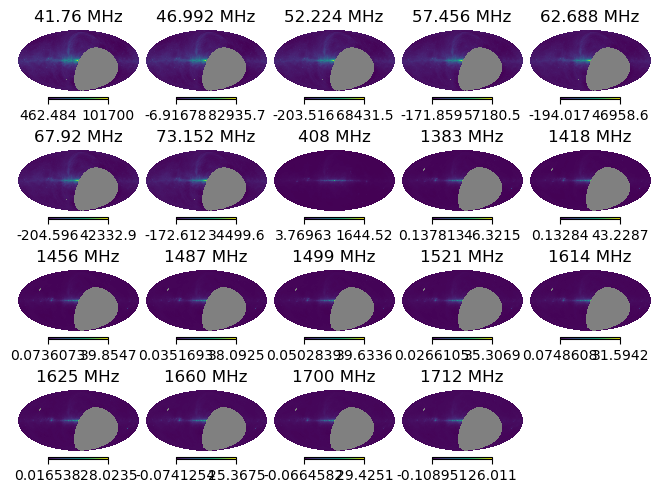

In [5]:
label ="north"
udgrade= True    


######################
hdul = fits.open(f"../inputmaps/fine_{label}_maps_nside256.fits" ) 
df = pd.DataFrame()
cols = hdul[1].columns.names
cols = cols 

df['frequency'] = np.float64(cols  )/1e3
data = hdul[1].data

nfreq=len(cols)
mapserr_table = np.load(f"../inputmaps/fine_{label}_errors_dict.npz")
errv = [v  for v in mapserr_table.values() ] 
df['depth_i']= errv 

instrument = df.dropna(axis=1, how='all')
hdul.close()


freq_maps=hp.read_map(f"../inputmaps/fine_{label}_maps_nside256.fits",  field=cols  )

if udgrade:
    nside_new = 64
    
    noise_factor = np.sqrt(hp.nside2npix(hp.get_nside (freq_maps[0 ])) /hp.nside2npix( nside_new )  )
    #instrument['depth_i'] /= noise_factor
    j=0
    freq_maps_ud=[]
    for i  in range(nfreq ):
    
        mask =np.isnan(freq_maps[i] )
        freq_maps[i][mask]=hp.UNSEEN 

        freq_maps_ud.append( hp.ud_grade(freq_maps[i] , nside_out=nside_new   ))
    freq_maps=np.vstack(freq_maps_ud)


freq_maps= freq_maps.reshape( freq_maps.shape[0],1,  freq_maps.shape[1])

print(instrument ) 
for i  in range(nfreq ):
    hp.mollview(   freq_maps[i,0  ]     , 
                 title=f'{cols[i] } MHz'  , 
                sub=(4,5,1+i) , notext=True)

In [8]:


nside = 64  
options={'disp':False , 'gtol': 1e-18, 'eps': 1e-18,   'maxiter': 1000, 'ftol': 1e-18 }
tol = 1e-18
method='TNC'
components =[  Synchrotron(nu0=.045, running=None , nu_pivot=0.045  ,  units='K_RJ'  ) , 
                  FreeFree(nu0=.408 ,  units='K_RJ'  )
                    ]

print(components[0].n_param, components[1].n_param , hp.get_nside(freq_maps[0,:,:]) )
nsidepatches = [nside, nside , nside,nside   ]


#maskfreq=  df['frequency']<0.1 



maskfreq=  df['frequency']<0.40
print(instrument[~maskfreq] ) 


3 1 64
    frequency depth_i
7       0.408     0.1
8       1.383    0.02
9       1.418    0.02
10      1.456    0.02
11      1.487    0.02
12      1.499    0.02
13      1.521    0.02
14      1.614    0.02
15      1.625    0.02
16      1.660    0.02
17      1.700    0.02
18      1.712    0.02


## run north 

In [36]:
results   = sr.multi_res_comp_sep(components, instrument[~maskfreq] , freq_maps[~maskfreq] ,
                                  nsides= nsidepatches ,
                                    method=method,
                                    tol = tol,
                                     options=options,
                                    #bounds=bounds,
                                    )
#np.savez(f'../outputs/fgbuster_params_{label}_nside{nside}_fine.npz',
#                  **{n: a for n, a in zip(results.params, results.x)})

KeyboardInterrupt: 

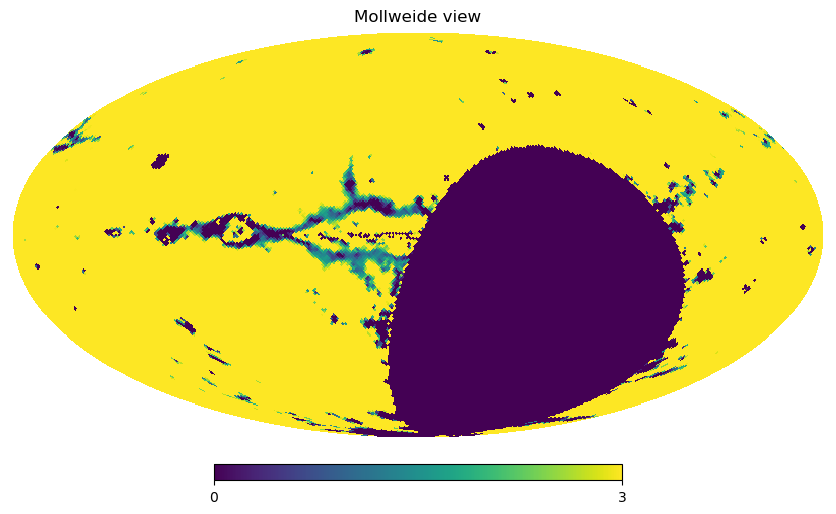

In [10]:
hp.mollview(results.chi.sum(axis=0)[0] /(freq_maps[~maskfreq].shape[0]  - len(results.params) ), min=0,max=3) 
pl.show() 


In [35]:
tmp =results.invAtNA[:,0,1,1].copy() 
mask =(freq_maps[i,0] ==hp.UNSEEN )
print(mask.shape) 
tmp[mask]=hp.UNSEEN 
hp.mollview(np.log10(tmp),   ) 

(49152,)


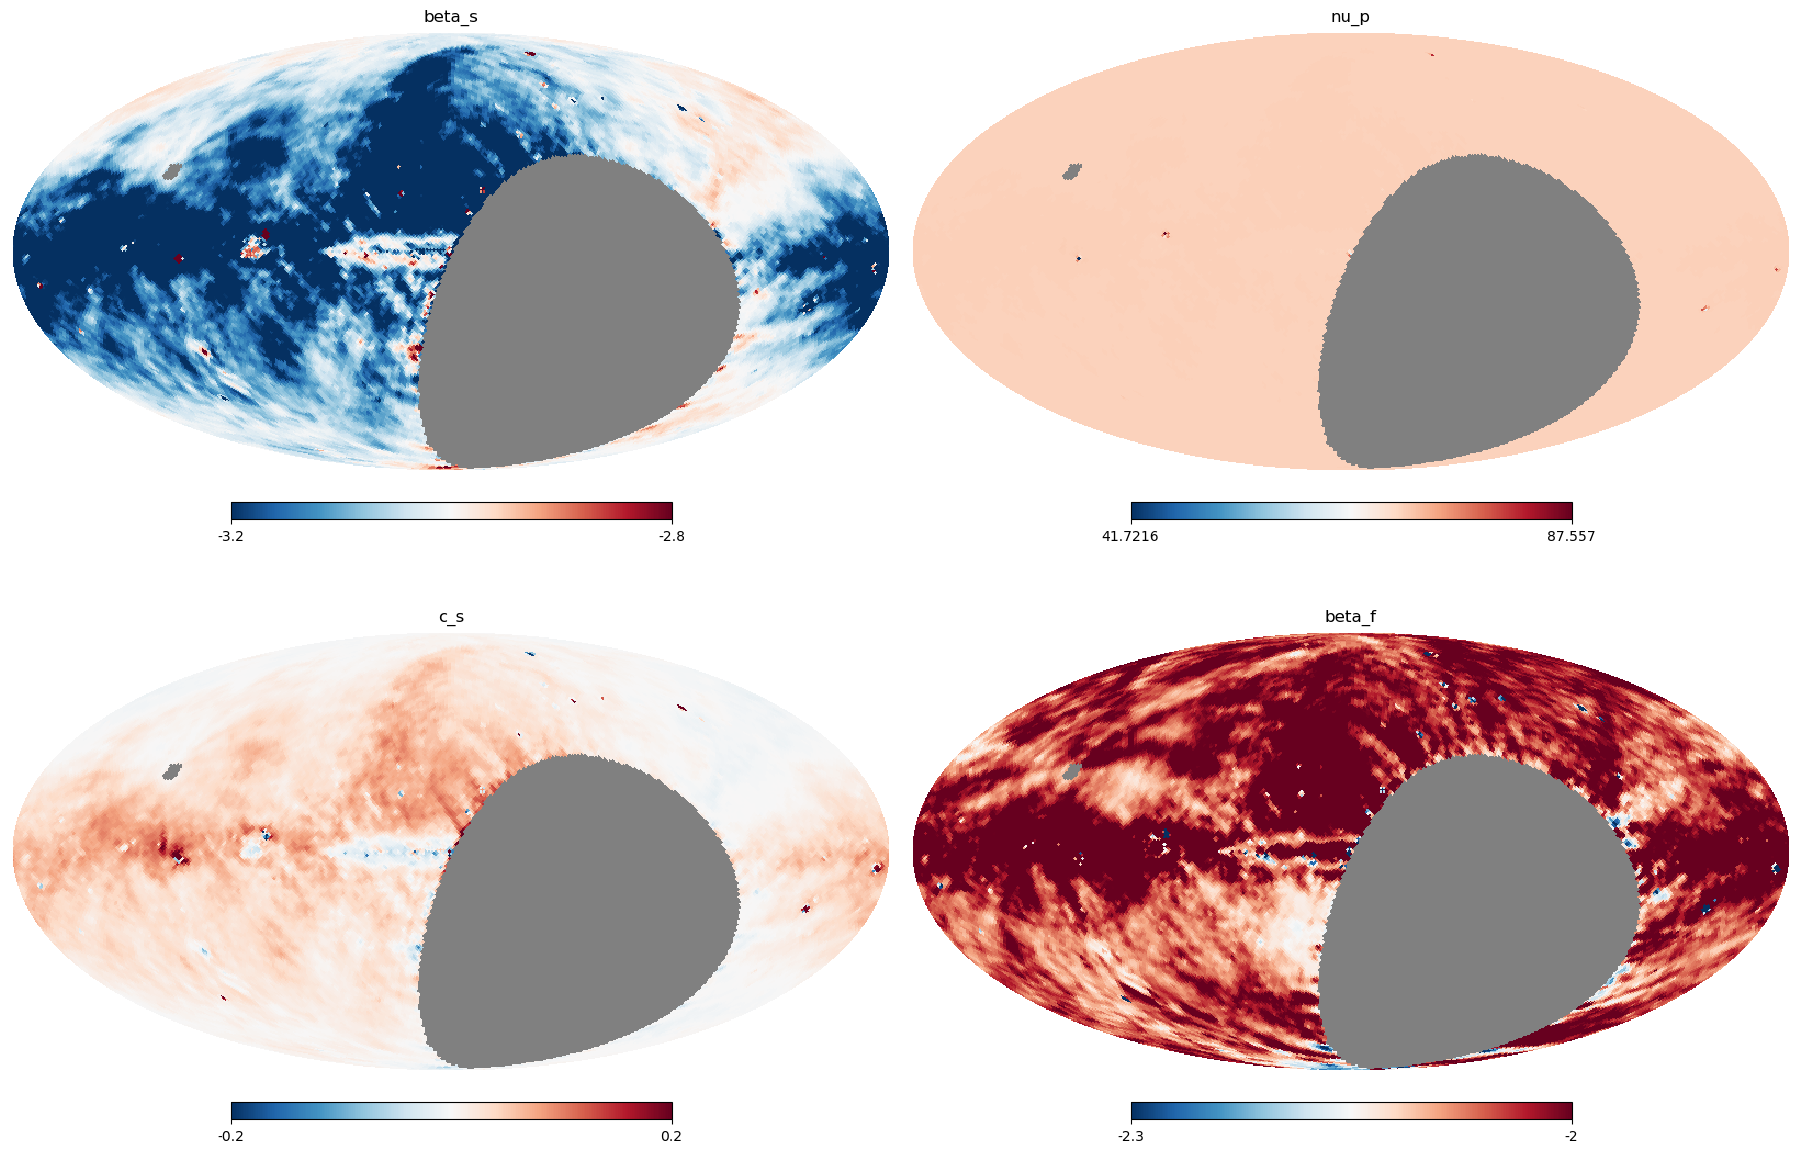

In [15]:
pl.figure( figsize=(18, 12))

betas =  (results.x_map[0])  
nup =  (results.x_map[1])
cs =results.x_map[2]  
betaf =results.x_map[3]  
hp.mollview(betas , title='beta_s' , cmap='RdBu_r', min=-3.2,max=-2.8,sub=221   )
hp.mollview(nup , title='nu_p' , cmap='RdBu_r' , sub=222)
hp.mollview(cs , title='c_s' , cmap='RdBu_r' , min=-0.2, max=0.2   , sub=223 )  
hp.mollview(betaf , title='beta_f' , cmap='RdBu_r', min=-2.3, max=-2.0 , sub=224)



In [9]:
results.message

'Linear search failed'

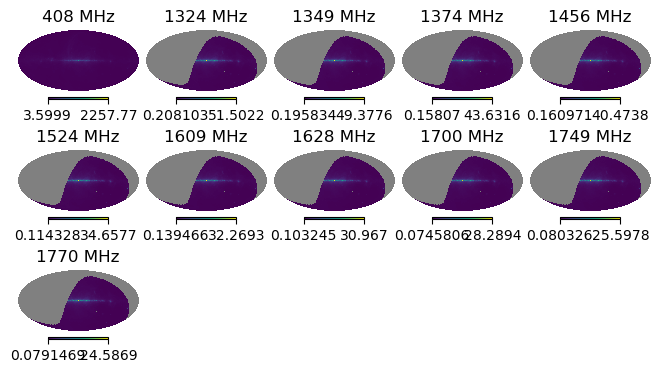

In [22]:
label ="south"
udgrade= True  


######################
hdul = fits.open(f"../inputmaps/fine_{label}_maps_nside256.fits" ) 
df = pd.DataFrame()
cols = hdul[1].columns.names
cols = cols 
df['frequency'] = np.float_(cols  )/1e3
data = hdul[1].data

nfreq=len(cols)
mapserr_table = np.load(f"../inputmaps/fine_{label}_errors_dict.npz")
errv = [v for v in mapserr_table.values() ] 
df['depth_i']= errv 
instrument = df.dropna(axis=1, how='all')
hdul.close()

freq_maps=hp.read_map(f"../inputmaps/fine_{label}_maps_nside256.fits",  field=cols  )

if udgrade:
    nside_new = 64
    noise_factor = np.sqrt(hp.nside2npix(hp.get_nside (freq_maps[0 ])) /hp.nside2npix( nside_new )  )
    #instrument['depth_i'] /= noise_factor
    j=0
    freq_maps_ud=[]
    for i  in range(nfreq ):
    
        mask =np.isnan(freq_maps[i] )
        freq_maps[i][mask]=hp.UNSEEN 

        freq_maps_ud.append( hp.ud_grade(freq_maps[i] , nside_out=nside_new   ))
    freq_maps=np.vstack(freq_maps_ud)


freq_maps= freq_maps.reshape( freq_maps.shape[0],1,  freq_maps.shape[1])


for i  in range(nfreq ):
    hp.mollview(   freq_maps[i,0  ]     , 
                 title=f'{cols[i] } MHz'  , 
                sub=(4,5,1+i) , notext=True)

In [ ]:
instrument

## run south 

In [23]:


results   = sr.multi_res_comp_sep(components, instrument, freq_maps,  
                                  nsides= nsidepatches ,
                                    method=method,
                                    tol = tol,
                                     options=options,
                                    #bounds=bounds,
                                    )

np.savez(f'../outputs/fgbuster_params_{label}_nside{nside}_fine.npz',
                  **{n: a for n, a in zip(results.params, results.x)})

SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> l

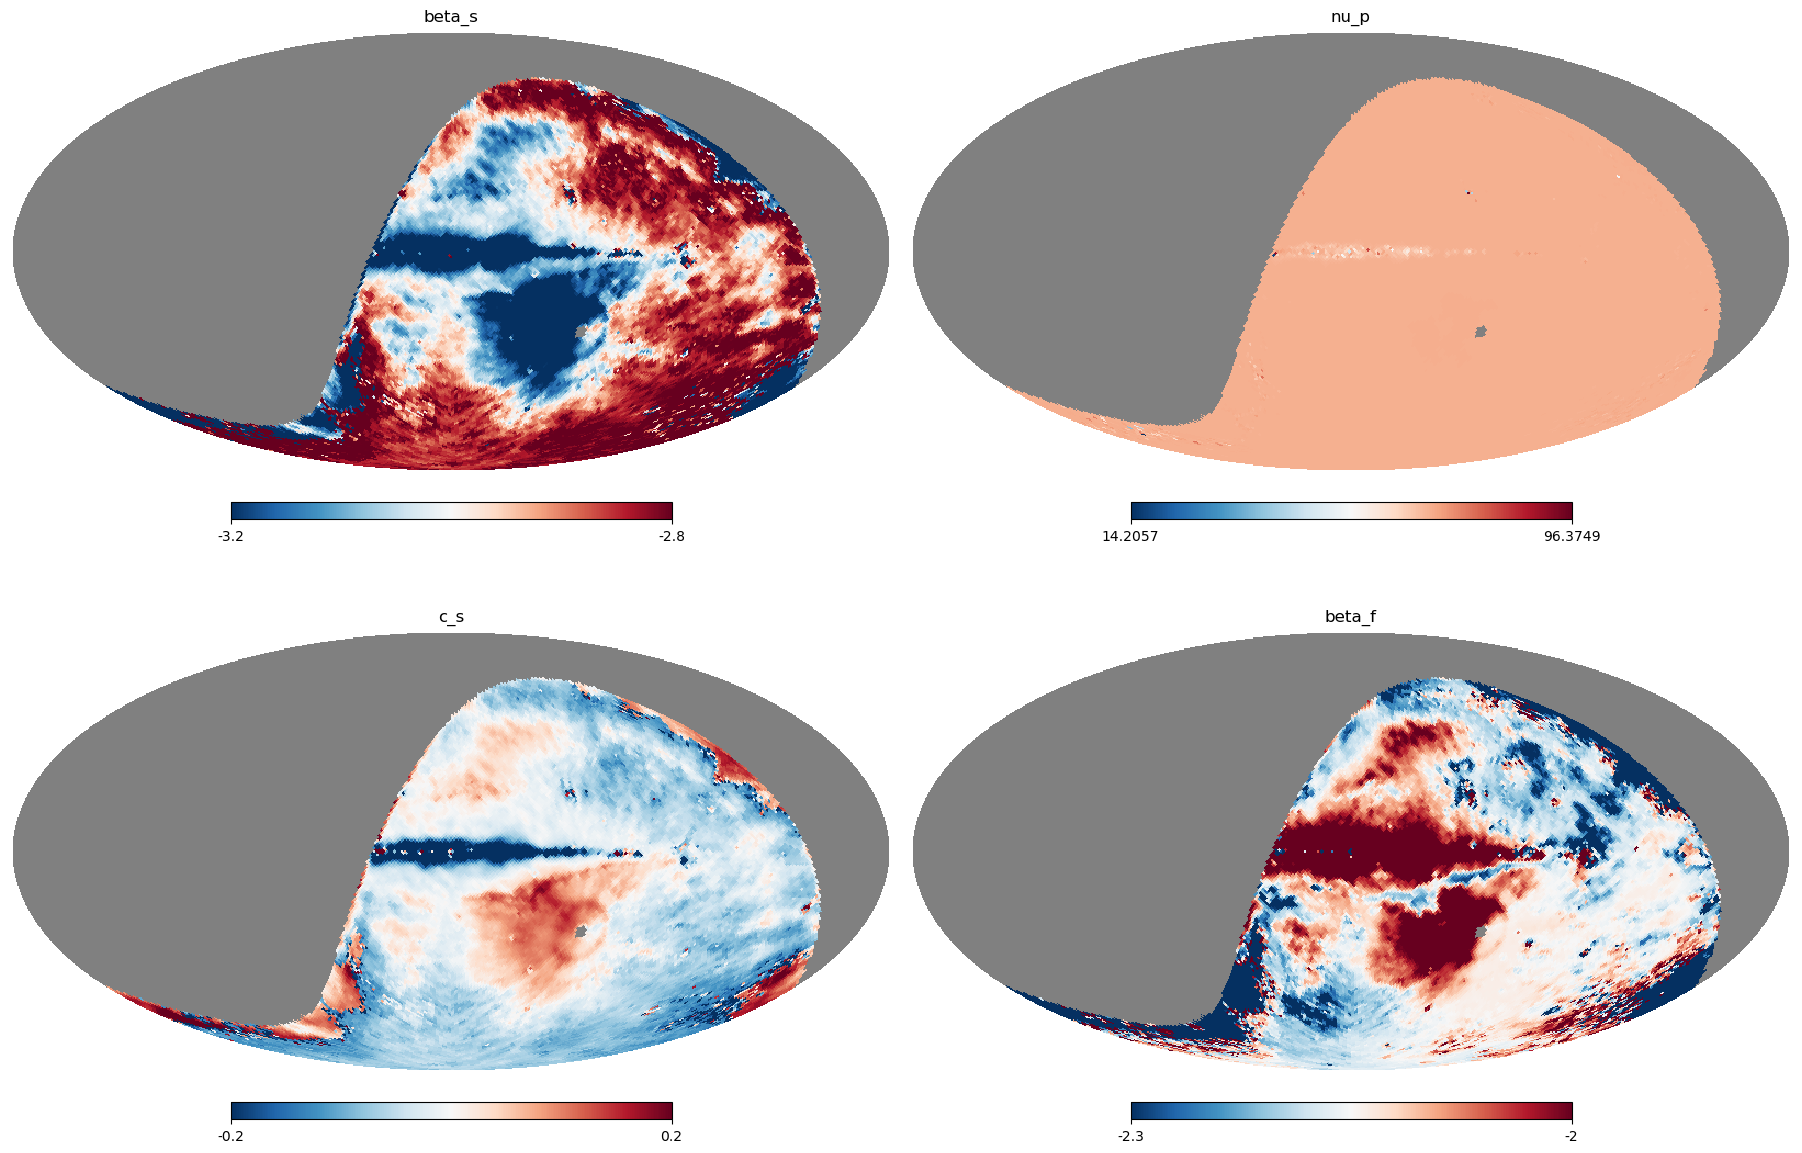

In [24]:
pl.figure( figsize=(18, 12))

betas =  (results.x_map[0])  
nup =  (results.x_map[1])
cs =results.x_map[2]  
betaf =results.x_map[3]  
hp.mollview(betas , title='beta_s' , cmap='RdBu_r', min=-3.2,max=-2.8,sub=221   )
hp.mollview(nup , title='nu_p' , cmap='RdBu_r' , sub=222)
hp.mollview(cs , title='c_s' , cmap='RdBu_r' , min=-0.2, max=0.2   , sub=223 )  
hp.mollview(betaf , title='beta_f' , cmap='RdBu_r', min=-2.3, max=-2.0 , sub=224)



## combine data

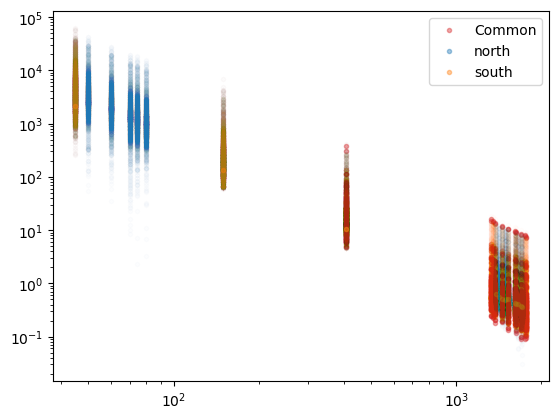

In [25]:
y = freq_maps[:,0,::200]

freqs = np.asarray(instrument['frequency'])

    # 1) scatter all samples (fast)
x = np.repeat(freqs[:, None], y.shape[1], axis=1)*1e3  # same shape as y
pl.semilogy (x, y ,f'C{3}.', alpha=0.4 )
pl.semilogy (x[:,0], y[:,0] ,f'C{3}.' , alpha=.4, label="Common" )
labels = ['north', 'south' ] 
udgrade= False 
jj=0
for   label in  (labels):
    ######################
    hdul = fits.open(f"../inputmaps/coarse_{label}_maps_nside256.fits" ) 
    df = pd.DataFrame()
    cols = hdul[1].columns.names
    cols = cols 
    df['frequency'] = np.float_(cols  )/1e3
    data = hdul[1].data

    nfreq=len(cols)
    mapserr_table = np.load(f"../inputmaps/coarse_{label}_errors_dict.npz")
    errv = [v for v in mapserr_table.values() ] 
    df['depth_i']= errv 
    instrument = df.dropna(axis=1, how='all')
    hdul.close()

    freq_maps=hp.read_map(f"../inputmaps/coarse_{label}_maps_nside256.fits",  field=cols  )


    if udgrade:
        nside_new = 64
        noise_factor = np.sqrt(hp.nside2npix(hp.get_nside (freq_maps[0 ])) /hp.nside2npix( nside_new )  )
        instrument['depth_i'] /= noise_factor
        j=0
        freq_maps_ud=[]
        for i  in range(nfreq ):
        
            mask =np.isnan(freq_maps[i] )
            freq_maps[i][mask]=hp.UNSEEN 

            freq_maps_ud.append( hp.ud_grade(freq_maps[i] , nside_out=nside_new   ))
        freq_maps=np.vstack(freq_maps_ud)


    freq_maps= freq_maps.reshape( freq_maps.shape[0],1,  freq_maps.shape[1])
    y = freq_maps[:,0,::200]

    freqs = np.asarray(instrument['frequency'])

    # 1) scatter all samples (fast)
    x = np.repeat(freqs[:, None], y.shape[1], axis=1)*1e3  # same shape as y
    pl.semilogy (x, y ,f'C{jj}.', alpha=0.01 )
    pl.semilogy (x[:,0], y[:,0] ,f'C{jj}.' , alpha=.4, label=label )
    pl.legend() 
    pl.loglog() 

    jj+=1

50 0.02984293018368328
100 0.014151911121212078
150 0.008267801545283626
200 0.0053167843793202
250 0.0036378454562320957
272
50 0.03841670449548681
100 0.01799563429057939
117
50 0.008964402481359964
100 0.004290475740247168
150 0.0025420175534209455
162
50 0.02633642961547326
100 0.011049550300782772
150 0.005650701737568642
200 0.0032811819399372437
201


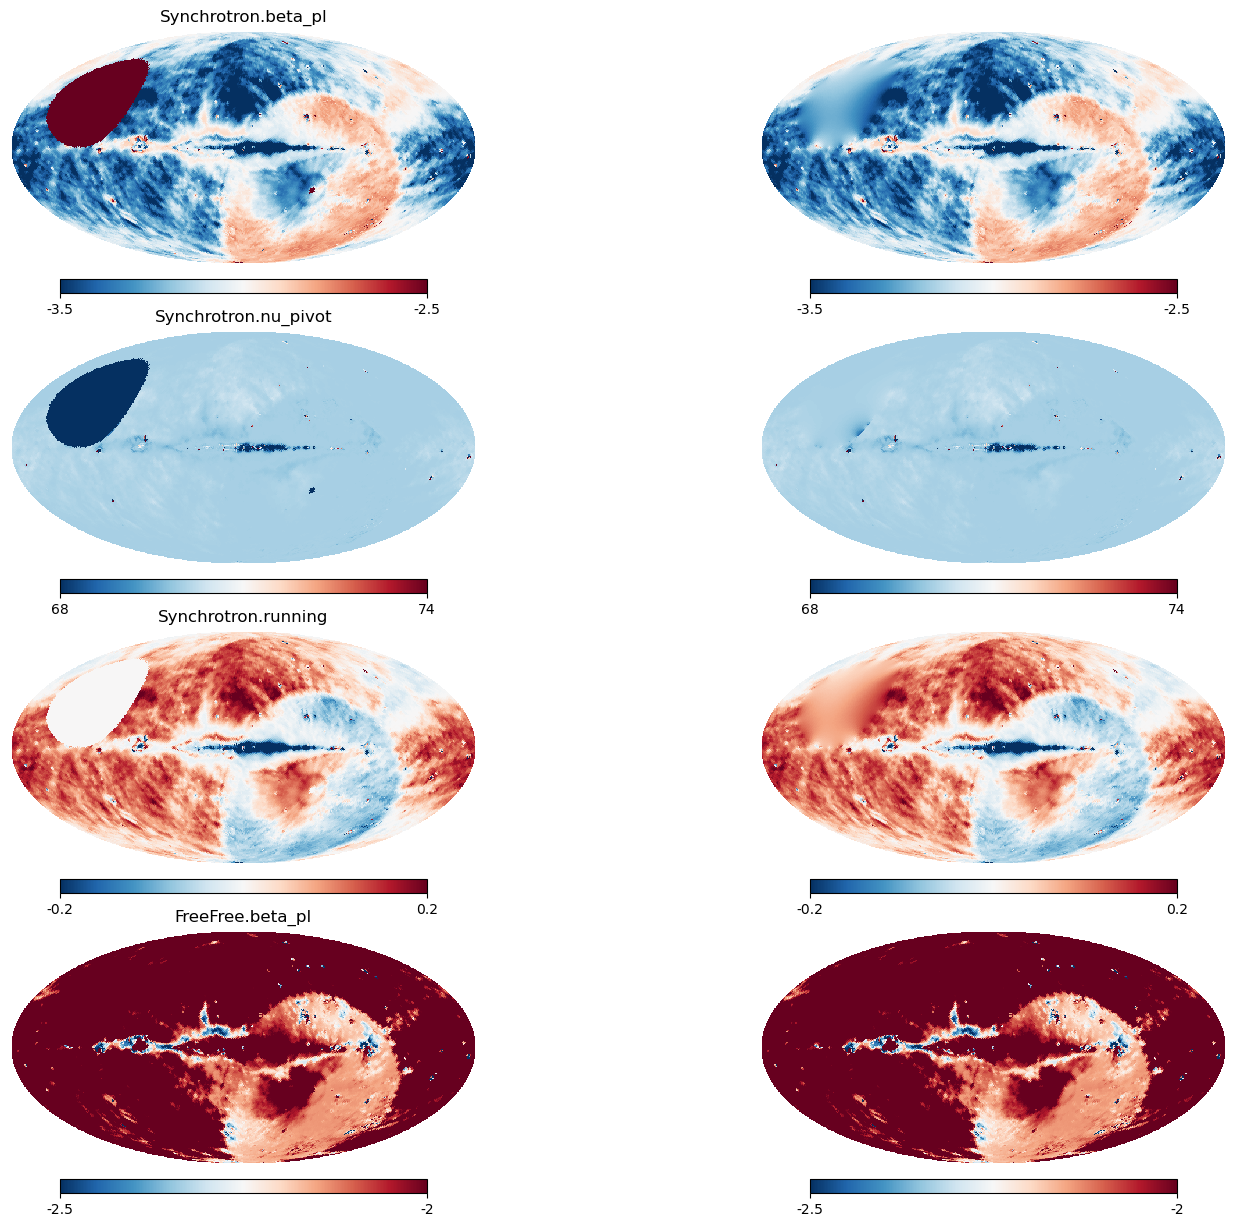

In [34]:
nside=64
common_apo =hp.read_map('../common_south_north_apo.fits' )
valid_north = hp.read_map(f"../valid_north_apo.fits" )
valid_south = hp.read_map(f"../valid_south_apo.fits" )
combined_dic ={} 

kk=0
pl.figure(figsize=(15,12)    )
for comp, comps  in zip(["Synchrotron", "FreeFree"], components):
    for p in comps.params: 
        
        if comp =="Synchrotron" and p=="running":
            min=-0.2
            max=0.2
        elif comp =="Synchrotron" and p=="beta_pl":
            min=-3.5
            max=-2.5

        elif comp =="FreeFree" and p=="beta_pl":
            min=-2.5
            max=-2.
        else: 
            min=68
            max=74 
        resnorth = np.load(f'../outputs/fgbuster_params_north_nside{nside}_fine.npz' )[f"{comp}.{p}"]
        ressouth = np.load(f'../outputs/fgbuster_params_south_nside{nside}_fine.npz' )[f"{comp}.{p}"]
        nan_north = resnorth == hp.UNSEEN
        nan_south = ressouth == hp.UNSEEN

        ressouth [nan_south]= 0.
        resnorth [nan_north]= 0. 
        valid_south=1- valid_north 

        common_apo = np.ma.masked_outside (valid_north ,1e-14, .99999 ).mask 
        disc = hp.query_disc(nside, vec= hp.ang2vec (theta=np.pi/3   ,phi=2./3*np.pi +.04*np.pi   ) , radius =np.radians(30)  , )

        apo_pixs = (1-nan_north )*common_apo
        weigths =np.ones (ressouth.shape )#+  (common_apo)  
        combined =   (ressouth *valid_south   + resnorth *valid_north  ) / ( weigths    )  
        combined[disc ]= 0. #( ressouth[apo_pixs ] + resnorth[apo_pixs ] )   

        hp.mollview(combined  ,sub=421+kk , min=min, max=max, cmap='RdBu_r' , title=comp+"." +p )

        holes = np.where(combined == 0.  ) [0] 

        combined[holes]= np.nan 
        nside= hp.get_nside(combined)
        theta,phi = hp.pix2ang(ipix=holes, nside=nside, lonlat=False)
        neighbs = hp.get_all_neighbours(nside,theta,phi, lonlat=False)
         

        c=0
        while True:
            tmp = combined[holes].copy() 
            for jj, ipix in enumerate(holes) : 
                fill_neighb = ~pl.ma.masked_invalid(combined[neighbs[:, jj]] ).mask 
                
                combined[ipix] = pl.mean(combined[neighbs[fill_neighb, jj] ])
            if pl.allclose(combined[holes], tmp,atol=1e-4  ): break 
            c+=1

            if c%50==0: 
                print(c, pl.linalg.norm(combined[holes] - tmp ))  
                #pl.figure() 
                #hp.mollview(m-morig,sub=122) 
            #if c>500: break 

        print(c )
        hp.mollview(combined  ,sub=422+kk , min=min, max=max, cmap='RdBu_r', title= ''  )
        combined_dic[f"{comp}.{p}"]= combined 
        kk+=2

    
pl.show() 


In [35]:
np.savez(f'../outputs/fgbuster_filled_maps_nside{nside}_fine.npz',
                  **{n: a for n, a in zip(combined_dic.keys(), combined_dic.values())}) 

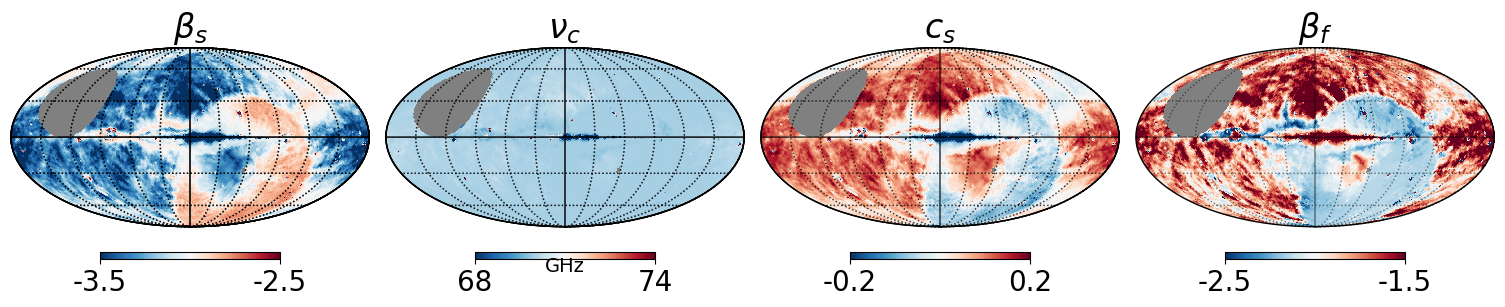

In [67]:
nside=64
common_apo =hp.read_map('../common_south_north_apo.fits' )
valid_north = hp.read_map(f"../valid_north_apo.fits" )
valid_south = hp.read_map(f"../valid_south_apo.fits" )
combined_dic ={} 

kk=0
pl.figure(figsize=(15,5)    )
import matplotlib
matplotlib.rcParams.update({'font.size': 20})
for comp, comps  in zip(["Synchrotron", "FreeFree"], components):
    for p in comps.params: 
        units=None 
        if comp =="Synchrotron" and p=="running":
            label = r'$c_s$' 
            min=-0.2
            max=0.2
        elif comp =="Synchrotron" and p=="beta_pl":
            label = r'$\beta_s$' 
            
            min=-3.5
            max=-2.5

        elif comp =="FreeFree" and p=="beta_pl":
            label = r'$\beta_f$' 
            
            min=-2.5
            max=-1.5
        else: 
            label = r'$\nu_c$' 
            units='GHz' 
            min=68
            max=74 
        resnorth = np.load(f'../outputs/fgbuster_params_north_nside{nside}_fine.npz' )[f"{comp}.{p}"]
        ressouth = np.load(f'../outputs/fgbuster_params_south_nside{nside}_fine.npz' )[f"{comp}.{p}"]
        nan_north = resnorth == hp.UNSEEN
        nan_south = ressouth == hp.UNSEEN

        ressouth [nan_south]= 0.
        resnorth [nan_north]= 0. 
        valid_south=1- valid_north 

        common_apo = np.ma.masked_outside (valid_north ,1e-14, .99999 ).mask 
        disc = hp.query_disc(nside, vec= hp.ang2vec (theta=np.pi/3   ,phi=2./3*np.pi +.04*np.pi   ) , radius =np.radians(30)  , )

        apo_pixs = (1-nan_north )*common_apo
        weigths =np.ones (ressouth.shape )#+  (common_apo)  
        combined =   (ressouth *valid_south   + resnorth *valid_north  ) / ( weigths    )  
        combined[disc ]= 0. #( ressouth[apo_pixs ] + resnorth[apo_pixs ] )   


        holes = np.where(combined == 0.  ) [0] 

        combined[holes]= np.nan 
        hp.mollview(combined  ,sub=141+kk ,title=label,  notext=False , unit=units, min=min, max=max, cmap='RdBu_r' )
        hp.graticule(alpha=.5) 
        kk+=1

pl.tight_layout() 
pl.savefig('fgb_fine.pdf') 
pl.show()

In [46]:
hp.__version__

'1.18.1'